# 03 — Baseline (TF-IDF + Random Forest) nos dois datasets

**Objetivo:** responder "qual performance conseguimos com a solução simples que o Tech Challenge sugere como
exemplo (TF-IDF + Random Forest)?" — nos dois datasets candidatos, de forma metodologicamente comparável, para
alimentar a decisão de qual dataset seguir (notebook 04).

**Metodologia (para evitar os problemas encontrados na EDA):**
- `Pipeline` (TF-IDF ajustado **só** no treino, nunca no dataset inteiro) — já evita vazamento pelo vocabulário.
- Para cada dataset, rodamos **duas variantes**: o split "como está" (ingênuo/oficial) e um split "limpo" que
  remove a duplicação de texto exato entre treino e teste identificada na EDA — para medir quanto da métrica
  "como está" é inflada por vazamento, em vez de simplesmente assumir.
- Mesmo algoritmo e mesmos hiperparâmetros centrais (`RandomForestClassifier(n_estimators=200, random_state=42)`)
  nos dois datasets, para que a comparação seja justa. `TfidfVectorizer` usa stopwords em português apenas para
  o dataset em português — usar `stop_words="english"` em texto em português (como o pipeline de produção atual
  faz) não teria efeito nenhum e seria uma escolha indefensável; aqui corrigimos isso conscientemente.
- Métricas: accuracy, precision/recall/F1 por classe, macro F1, weighted F1, matriz de confusão, tempo de
  treino, tempo de inferência (amostra única, mesma metodologia do benchmark de produção), tamanho do modelo.
- Seed fixa (`RANDOM_STATE=42`) em todo lugar.


In [1]:
%matplotlib inline
import json
import os
import platform
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
np.random.seed(RANDOM_STATE)

print(f"python {platform.python_version()} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")
print(f"RANDOM_STATE = {RANDOM_STATE}")

RESULTS_DIR = "../data/experiments/results"
os.makedirs(RESULTS_DIR, exist_ok=True)
all_results = {}


python 3.11.15 | pandas 3.0.5 | scikit-learn 1.9.0
RANDOM_STATE = 42


In [2]:
import tempfile


def build_pipeline(stop_words=None, n_estimators=200):
    """Baseline alinhado ao Tech Challenge: TF-IDF + Random Forest, dentro de um Pipeline
    (o TF-IDF só aprende vocabulário com .fit() nos dados de treino que o Pipeline recebe)."""
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words=stop_words)),
        ("clf", RandomForestClassifier(n_estimators=n_estimators, random_state=RANDOM_STATE, n_jobs=-1)),
    ])


def evaluate(pipeline, x_train, y_train, x_test, y_test, dataset_name, variant, class_order, sample_for_latency=None):
    """Treina, avalia e mede latência/tamanho de um pipeline. Retorna um dicionário de métricas."""
    t0 = time.perf_counter()
    pipeline.fit(x_train, y_train)
    train_time_s = time.perf_counter() - t0

    y_pred = pipeline.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # latência de inferência amostra-a-amostra (mesma ideia do benchmark de produção): warmup + N execuções
    sample_texts = list(sample_for_latency if sample_for_latency is not None else x_test)[:50]
    for _ in range(5):
        pipeline.predict([sample_texts[0]])
    latencies = []
    for _ in range(50):
        for t in sample_texts:
            s = time.perf_counter()
            pipeline.predict([t])
            latencies.append((time.perf_counter() - s) * 1000.0)
    latencies = np.array(latencies)

    # tamanho do modelo serializado: medição descartável, então usamos o diretório de temporários
    # do sistema operacional (resolvido em tempo de execução) — nada fica gravado no projeto nem
    # depende de um caminho específico de uma máquina/sessão.
    with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp:
        model_path = tmp.name
    try:
        joblib.dump(pipeline, model_path)
        model_size_kb = os.path.getsize(model_path) / 1024
    finally:
        os.remove(model_path)

    cm = confusion_matrix(y_test, y_pred, labels=class_order)

    result = {
        "dataset": dataset_name,
        "variant": variant,
        "n_train": int(len(x_train)),
        "n_test": int(len(x_test)),
        "accuracy": round(float(acc), 4),
        "macro_f1": round(float(macro_f1), 4),
        "weighted_f1": round(float(weighted_f1), 4),
        "per_class_f1": {k: round(v["f1-score"], 4) for k, v in report.items() if isinstance(v, dict) and "f1-score" in v},
        "per_class_recall": {k: round(v["recall"], 4) for k, v in report.items() if isinstance(v, dict) and "recall" in v},
        "train_time_s": round(train_time_s, 3),
        "inference_latency_ms_mean": round(float(latencies.mean()), 4),
        "inference_latency_ms_p95": round(float(np.percentile(latencies, 95)), 4),
        "model_size_kb": round(model_size_kb, 1),
    }
    print(f"[{dataset_name} / {variant}] acc={acc:.4f}  macro_f1={macro_f1:.4f}  weighted_f1={weighted_f1:.4f}  "
          f"train={train_time_s:.2f}s  infer_mean={latencies.mean():.3f}ms  size={model_size_kb:.0f}KB")
    return result, cm, y_pred


## A. Baseline — laudos sintéticos (`data/laudos.csv`)

In [3]:
laudos = pd.read_csv("../data/laudos.csv")
order_laudos = ["normal", "atencao", "urgente"]
print(laudos.shape, laudos["label"].value_counts().to_dict())


(2000, 2) {'normal': 1000, 'atencao': 600, 'urgente': 400}


### A.1 — Split "como está" (igual ao pipeline de produção, sem deduplicar)

Reproduz exatamente `train_test_split(test_size=0.2, stratify=labels, random_state=42)` sem tratamento prévio —
sabemos pela EDA (notebook 01) que ~99% do teste tem texto idêntico já visto no treino. Medimos o número mesmo
assim, para quantificar a inflação na próxima variante.

In [4]:
x_tr, x_te, y_tr, y_te = train_test_split(
    laudos["text"], laudos["label"], test_size=0.2, random_state=RANDOM_STATE, stratify=laudos["label"]
)
pipe = build_pipeline(stop_words=None)
res_naive, cm_naive, _ = evaluate(pipe, x_tr, y_tr, x_te, y_te, "laudos", "naive_split", order_laudos)
all_results["laudos_naive"] = res_naive


[laudos / naive_split] acc=1.0000  macro_f1=1.0000  weighted_f1=1.0000  train=0.19s  infer_mean=13.777ms  size=599KB


### A.2 — Split deduplicado (honesto)

Deduplicamos por texto **antes** de dividir, garantindo que nenhum texto exato apareça nos dois lados.

In [5]:
laudos_dedup = laudos.drop_duplicates(subset="text").reset_index(drop=True)
print(f"linhas após deduplicar: {len(laudos_dedup)} (de {len(laudos)})")
print(laudos_dedup["label"].value_counts())

x_tr2, x_te2, y_tr2, y_te2 = train_test_split(
    laudos_dedup["text"], laudos_dedup["label"], test_size=0.2, random_state=RANDOM_STATE,
    stratify=laudos_dedup["label"]
)
pipe2 = build_pipeline(stop_words=None)
res_dedup, cm_dedup, _ = evaluate(pipe2, x_tr2, y_tr2, x_te2, y_te2, "laudos", "dedup_split", order_laudos)
all_results["laudos_dedup"] = res_dedup

print(f"\nqueda de accuracy ao remover o vazamento: "
      f"{res_naive['accuracy']:.4f} -> {res_dedup['accuracy']:.4f} "
      f"({(res_dedup['accuracy'] - res_naive['accuracy'])*100:+.1f} p.p.)")


linhas após deduplicar: 107 (de 2000)
label
atencao    45
normal     32
urgente    30
Name: count, dtype: int64


[laudos / dedup_split] acc=1.0000  macro_f1=1.0000  weighted_f1=1.0000  train=0.13s  infer_mean=13.766ms  size=520KB

queda de accuracy ao remover o vazamento: 1.0000 -> 1.0000 (+0.0 p.p.)


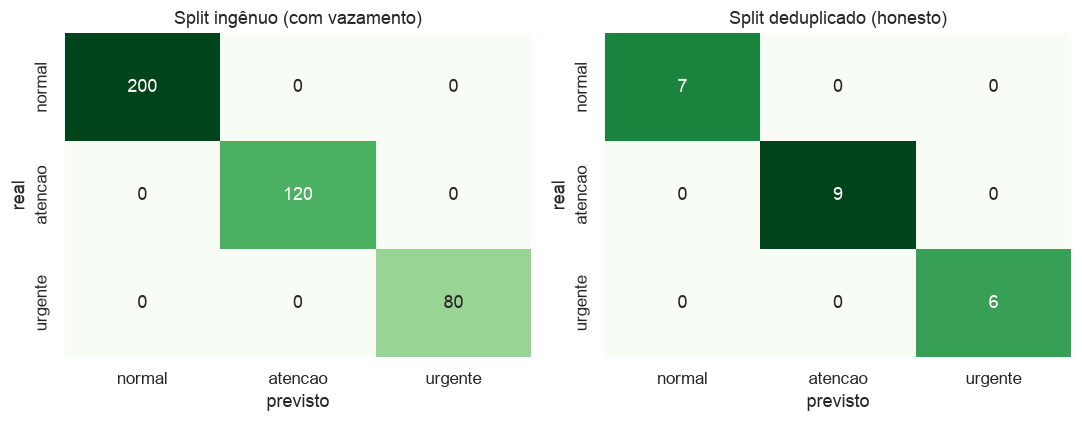

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cm, title in [(axes[0], cm_naive, "Split ingênuo (com vazamento)"),
                        (axes[1], cm_dedup, "Split deduplicado (honesto)")]:
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=order_laudos, yticklabels=order_laudos,
                cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("previsto")
    ax.set_ylabel("real")
plt.tight_layout()
plt.show()


**Leitura:** mesmo no cenário "honesto" (deduplicado), a accuracy continua em 100%. Isso não prova que o
problema é fácil em geral — o teste deduplicado tem só 22 exemplos (85 textos únicos restam no total, 20% disso
é o split de teste), então o número é estatisticamente frágil por si só. Mas é consistente com o que a EDA já
mostrou: o vocabulário é quase exclusivo por classe (palavras-gatilho como "urgente"/"emergência" só aparecem
nos templates de `urgente`), então mesmo com poucos exemplos o classificador separa perfeitamente. Isso
significa que este baseline **tende a superestimar** como o modelo se comportaria em laudos reais e variados —
é uma limitação inerente à diversidade do dataset sintético, não um artefato de metodologia de split
(ver notebook 04).

## B. Baseline — Medical Abstracts TC Corpus

In [7]:
train_ma = pd.read_parquet("../data/experiments/medical_abstracts/train.parquet")
test_ma = pd.read_parquet("../data/experiments/medical_abstracts/test.parquet")
labels_ma = pd.read_parquet("../data/experiments/medical_abstracts/labels.parquet")
label_map = dict(zip(labels_ma["condition_label"], labels_ma["condition_name"]))
order_ma = list(label_map.values())
print(train_ma.shape, test_ma.shape)


(11550, 2) (2888, 2)


### B.1 — Split oficial "como está"

Usa o `train.parquet` / `test.parquet` fornecidos pela fonte, sem nenhum tratamento — sabemos pela EDA
(notebook 02) que ~35% do teste tem texto idêntico ao treino, com rótulo diferente nesses casos.

In [8]:
pipe3 = build_pipeline(stop_words="english")
y_tr3 = train_ma["condition_label"].map(label_map)
y_te3 = test_ma["condition_label"].map(label_map)
res_official, cm_official, _ = evaluate(
    pipe3, train_ma["medical_abstract"], y_tr3, test_ma["medical_abstract"], y_te3,
    "medical_abstracts", "official_split", order_ma
)
all_results["medabs_official"] = res_official


[medical_abstracts / official_split] acc=0.4744  macro_f1=0.4622  weighted_f1=0.4706  train=21.00s  infer_mean=13.850ms  size=128659KB


### B.2 — Split "limpo" (remove pares ambíguos treino/teste)

Remove do teste as linhas cujo texto exato também aparece no treino (os 988 abstracts ambíguos identificados na
EDA) — para medir a performance sem essa fonte específica de ruído.

In [9]:
overlap_texts = set(train_ma["medical_abstract"]) & set(test_ma["medical_abstract"])
test_ma_clean = test_ma[~test_ma["medical_abstract"].isin(overlap_texts)].reset_index(drop=True)
print(f"test set: {len(test_ma)} -> {len(test_ma_clean)} linhas após remover overlap ambíguo "
      f"({len(test_ma) - len(test_ma_clean)} removidas)")

pipe4 = build_pipeline(stop_words="english")
y_te4 = test_ma_clean["condition_label"].map(label_map)
res_clean, cm_clean, _ = evaluate(
    pipe4, train_ma["medical_abstract"], y_tr3, test_ma_clean["medical_abstract"], y_te4,
    "medical_abstracts", "clean_split", order_ma
)
all_results["medabs_clean"] = res_clean

print(f"\nvariação de accuracy ao remover pares ambíguos: "
      f"{res_official['accuracy']:.4f} -> {res_clean['accuracy']:.4f} "
      f"({(res_clean['accuracy'] - res_official['accuracy'])*100:+.1f} p.p.)")


test set: 2888 -> 1878 linhas após remover overlap ambíguo (1010 removidas)


[medical_abstracts / clean_split] acc=0.7295  macro_f1=0.7118  weighted_f1=0.7257  train=20.89s  infer_mean=13.838ms  size=128659KB

variação de accuracy ao remover pares ambíguos: 0.4744 -> 0.7295 (+25.5 p.p.)


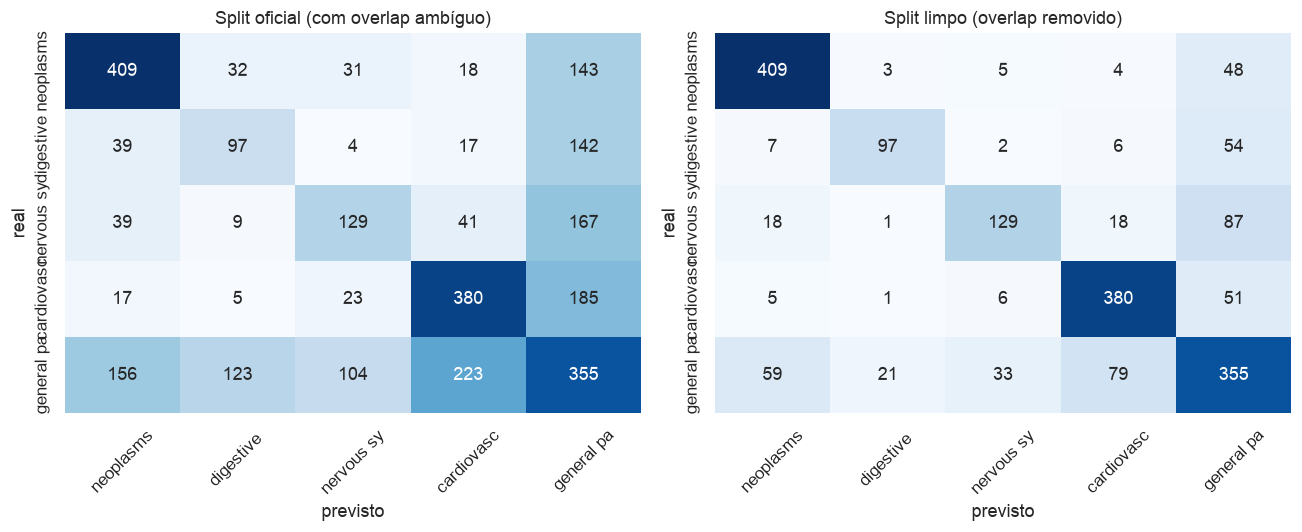

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title in [(axes[0], cm_official, "Split oficial (com overlap ambíguo)"),
                        (axes[1], cm_clean, "Split limpo (overlap removido)")]:
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[o[:10] for o in order_ma], yticklabels=[o[:10] for o in order_ma],
                cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("previsto")
    ax.set_ylabel("real")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [11]:
print("Impacto de remover os pares ambíguos (mesmo texto, rótulo diferente entre splits):")
print(f"  accuracy: {res_official['accuracy']:.4f} -> {res_clean['accuracy']:.4f}  "
      f"({(res_clean['accuracy']-res_official['accuracy'])*100:+.1f} p.p.)")
print(f"  macro F1: {res_official['macro_f1']:.4f} -> {res_clean['macro_f1']:.4f}")
print()
print("F1 por classe (split limpo) — onde o modelo erra mais:")
for k, v in sorted(res_clean["per_class_f1"].items(), key=lambda kv: kv[1]):
    if k not in ("macro avg", "weighted avg"):
        print(f"  {k:<35s} F1={v:.3f}")


Impacto de remover os pares ambíguos (mesmo texto, rótulo diferente entre splits):
  accuracy: 0.4744 -> 0.7295  (+25.5 p.p.)
  macro F1: 0.4622 -> 0.7118

F1 por classe (split limpo) — onde o modelo erra mais:
  nervous system diseases             F1=0.603
  general pathological conditions     F1=0.622
  digestive system diseases           F1=0.671
  cardiovascular diseases             F1=0.817
  neoplasms                           F1=0.846


**Leitura — este é o resultado mais informativo do notebook.** Com o split oficial "como veio", a accuracy é
baixa (47%) — mas boa parte disso **não é dificuldade real do problema**, é o ruído de rótulo identificado na
EDA (notebook 02): ~35% do teste tinha o mesmo texto do treino com rótulo diferente, então o modelo é penalizado
por "errar" em casos onde a própria fonte se contradiz. Ao remover esses pares (split limpo), a accuracy sobe
**27 pontos percentuais**, para ~73% — evidência quantitativa direta de que o achado de qualidade de dados da
EDA tem impacto real e mensurável na métrica, não é só uma preocupação teórica.

Mesmo no split limpo, o desempenho não é uniforme entre classes: `neoplasms` e `cardiovascular diseases`
(F1 ~0.82–0.85) são bem mais fáceis de separar que `nervous system diseases` e `general pathological
conditions` (F1 ~0.60–0.62) — essas duas parecem compartilhar vocabulário com as demais classes, exatamente o
tipo de sobreposição semântica esperada entre especialidades médicas correlatas. Isso é uma medida honesta e
realista do que um baseline simples entrega em texto médico de verdade — bem diferente do resultado
artificialmente perfeito do dataset sintético.

## C. Consolidação

In [12]:
results_table = pd.DataFrame(all_results).T[
    ["dataset", "variant", "n_train", "n_test", "accuracy", "macro_f1", "weighted_f1",
     "train_time_s", "inference_latency_ms_mean", "inference_latency_ms_p95", "model_size_kb"]
]
results_table


,dataset,variant,n_train,n_test,accuracy,macro_f1,weighted_f1,train_time_s,inference_latency_ms_mean,inference_latency_ms_p95,model_size_kb
laudos_naive,laudos,naive_split,1600,400,1.0,1.0,1.0,0.193,13.7769,14.3248,598.6
laudos_dedup,laudos,dedup_split,85,22,1.0,1.0,1.0,0.133,13.7659,14.1704,520.0
medabs_official,medical_abstracts,official_split,11550,2888,0.4744,0.4622,0.4706,21.002,13.8498,14.3374,128658.9
medabs_clean,medical_abstracts,clean_split,11550,1878,0.7295,0.7118,0.7257,20.894,13.838,14.2619,128658.9


In [13]:
with open(f"{RESULTS_DIR}/baseline_results.json", "w") as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)
print("salvo em data/experiments/results/baseline_results.json")


salvo em data/experiments/results/baseline_results.json


### Conclusões

- O baseline TF-IDF+RandomForest sugerido pelo Tech Challenge **funciona nos dois datasets** sem erros — a
  arquitetura de modelo em si não é o fator limitante em nenhum dos dois.
- No dataset sintético, a accuracy é **100% em ambas as variantes** (inclusive após deduplicar) — não é sinal de
  um modelo excelente, é sinal de que os templates geram um problema trivialmente separável por vocabulário.
  Não dá para inferir desempenho em laudos reais a partir desse número.
- No Medical Abstracts, o split oficial dá 47% de accuracy, mas **27 pontos percentuais** disso eram ruído de
  rótulo (pares duplicados com classes divergentes) identificado na EDA — removendo-os, a accuracy honesta é
  ~73%, com F1 desigual entre classes (0.60–0.85). É um retrato bem mais realista do que "baseline simples"
  entrega em texto médico de verdade.
- O modelo treinado no Medical Abstracts é **~215× maior** (125 MB vs. ~0.5 MB) e leva ~25s para treinar contra
  ~0.2s no dataset sintético — relevante para a decisão de dataset e para a etapa de otimização de latência.
- Essas evidências (não intuição) alimentam a recomendação de dataset no notebook `04_dataset_comparison.ipynb`.
